<a href="https://colab.research.google.com/github/sp6jaz/lecturesPythonII/blob/master/dzienne/W13/wyklad/advanced_libs_demo.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Dwie ścieżki pracy:**
- **Lokalna (zalecana)**: VS Code + venv + Jupyter — pełna kontrola, kod zostaje na Twoim komputerze.
- **Colab (kliknij i działa)**: środowisko Google gotowe w 5 sekund, działa nawet z telefonu. Kliknij ikonę powyżej.

# Zaawansowane biblioteki — scikit-learn, Plotly, Polars

**Programowanie w Pythonie II** | Wykład 13
**Politechnika Opolska** | Analityka danych w biznesie

---

## Co dzisiaj?

Przez dwanaście tygodni budowaliśmy **fundament**: NumPy, Pandas, Matplotlib, Seaborn, statystyka, testy hipotez. To jest rdzeń codziennej pracy z danymi — i ten rdzeń już znasz.

Ale jeśli otworzysz dowolne ogłoszenie o pracę dla analityka danych, zobaczysz trzy hasła, których jeszcze nie dotknęliśmy: **machine learning** (uczenie maszynowe), **interaktywne wykresy** i **„coś szybszego niż Pandas”**. Dzisiaj poznasz po jednym narzędziu z każdej z tych trzech rodzin — nie jako teorię, lecz jako narzędzie, którego możesz użyć w pracy w poniedziałek.

Każda z trzech bibliotek dostaje dziś **równo jedną trzecią** czasu — to przegląd, nie specjalizacja.

```mermaid
graph TD
    A["Masz dane<br/>(Pandas z W05-W08)"] --> B["scikit-learn<br/>uczenie maszynowe"]
    A --> C["Plotly<br/>interaktywne wykresy"]
    A --> D["Polars<br/>szybki DataFrame"]
    B --> E["Decyzja biznesowa"]
    C --> E
    D --> E
```

### Po tym wykładzie potrafisz:

1. **Wyjaśnić**, czym różni się uczenie nadzorowane (supervised — z etykietą) od nienadzorowanego (unsupervised — bez etykiety), i że model jest *uczony z danych*, a nie programowany ręcznie
2. **Stosować** `KMeans` (klasteryzacja — automatyczny podział na grupy) ze `StandardScaler` (normalizacja danych) do segmentacji klientów i interpretować segmenty biznesowo
3. **Projektować** pipeline regresji liniowej: `train_test_split` → `fit` → `predict` → ocena `R²` (współczynnik determinacji) i `RMSE` (typowy błąd prognozy)
4. **Tworzyć** interaktywne wykresy Plotly Express (`scatter`, `bar`, `line`) z hover (podpowiedź po najechaniu myszą) i zoomem oraz eksportować je do pliku HTML
5. **Stosować** Polars (`select`, `filter`, `group_by`, leniwa ewaluacja) i **oceniać**, kiedy warto sięgnąć po Polars zamiast Pandas

**Dokumentacja:** [scikit-learn](https://scikit-learn.org/stable/) | [Plotly Python](https://plotly.com/python/) | [Polars](https://docs.pola.rs/)

## 0. Trzy problemy, których fundament sam nie rozwiąże

Wyobraź sobie, że jesteś analitykiem w firmie e-commerce. W ostatni piątek dostajesz trzy zadania:

1. **Marketing**: „Mamy 300 klientów. Podziel ich na sensowne segmenty, żebyśmy mogli wysłać różne oferty.” — ale *nikt nie wie z góry*, jakie to mają być segmenty. Pandas tego nie zrobi — to zadanie dla **uczenia maszynowego**.
2. **Zarząd**: „Zrób wykres trendu sprzedaży, ale taki, żeby prezes mógł *najechać myszą* i zobaczyć dokładną wartość każdego miesiąca.” — statyczny obrazek z Matplotlib (W09) tego nie da. To zadanie dla **Plotly**.
3. **Dział danych**: „Mamy plik z 10 milionami transakcji. Twój skrypt w Pandas liczy go 4 minuty — skróć to.” — tu pomoże **Polars**.

Trzy zadania, trzy narzędzia. Dzisiaj dotykamy każdego. Zaczynamy od najważniejszego hasła z ogłoszeń o pracę: **scikit-learn**.

## 1. Przygotowanie środowiska

Trzy biblioteki, których jeszcze nie mamy w środowisku kursu, instalujemy **raz** — pierwszą komórką notebooka. `%pip` to magiczna komenda Jupytera (instaluje pakiet bez wychodzenia z notebooka), a `-q` oznacza *quiet* (cicho — bez długiego logu instalacji).

In [1]:
# Instalacja brakujących bibliotek (uruchom RAZ, potem zakomentuj)
# pyarrow jest potrzebny do mostu Pandas <-> Polars na kolumnach tekstowych
%pip install scikit-learn plotly polars pyarrow -q

Note: you may need to restart the kernel to use updated packages.


Importujemy wszystko, czego użyjemy. Zwróć uwagę na nazwy: instalujemy `scikit-learn`, ale importujemy `sklearn` (to częsta pułapka — patrz sekcja 6).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn — uczenie maszynowe
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Plotly — interaktywne wykresy
import plotly.express as px

# Polars — szybki DataFrame
import polars as pl

np.random.seed(42)  # powtarzalność: te same liczby losowe przy każdym uruchomieniu
print('Wszystkie biblioteki załadowane.')
print(f'scikit-learn {__import__("sklearn").__version__} | plotly {__import__("plotly").__version__} | polars {pl.__version__}')

Wszystkie biblioteki załadowane.
scikit-learn 1.9.0 | plotly 6.8.0 | polars 1.41.2


### Dataset przewodni — 300 klientów e-commerce

Generujemy dane w kodzie (`np.random.seed(42)` → identyczne wyniki u każdego). Dla każdego klienta mamy dwie cechy znane już z Pandas: **średnią wartość zamówienia** (w PLN) i **liczbę zamówień w roku**.

Celowo „ukrywamy” w danych trzy skupiska klientów — algorytm uczenia maszynowego ma je za chwilę *sam odkryć*, nie wiedząc, że tam są.

In [3]:
np.random.seed(42)

klienci = pd.DataFrame({
    'srednia_wartosc': np.concatenate([
        np.random.normal(400, 60, 100),    # grupa A — niskie wartości
        np.random.normal(1100, 120, 100),  # grupa B — średnie
        np.random.normal(2400, 180, 100),  # grupa C — wysokie
    ]),
    'zamowienia_rok': np.concatenate([
        np.random.normal(2, 0.5, 100),
        np.random.normal(7, 1.2, 100),
        np.random.normal(18, 2.5, 100),
    ]),
})
klienci = klienci.clip(lower=0)  # bez wartości ujemnych (cena/liczba nie bywa ujemna)
klienci.describe().round(1)

,srednia_wartosc,zamowienia_rok
count,300.0,300.0
mean,1302.7,8.9
std,847.9,6.7
min,242.8,0.9
25%,428.0,2.3
50%,1110.1,6.9
75%,2281.3,16.4
max,3093.5,23.7


> 💡 **Powtórka z W05-W08**: `describe()` daje statystyki opisowe, `clip(lower=0)` przycina wartości ujemne. To czysty Pandas — nasz punkt wyjścia. Cała magia dzisiaj zaczyna się *po* tym, jak dane są już w DataFrame.

## 2. scikit-learn — uczenie maszynowe (1/3)

**scikit-learn** to najważniejsza biblioteka uczenia maszynowego (machine learning, ML) w Pythonie. Zanim napiszemy choć linijkę — jeden próg pojęciowy do przekroczenia.

### 2.1. Czym jest „uczenie” maszynowe

Do tej pory programowaliśmy tak: człowiek pisze regułę (`if wartosc > 2000: segment = 'premium'`), a komputer ją wykonuje. W uczeniu maszynowym jest odwrotnie: **dajesz dane, a komputer sam znajduje regułę** (wzorzec). Model nie jest *zaprogramowany* — jest *uczony* z danych.

Dwie rodziny zadań:

| Rodzaj | Mamy etykietę (odpowiedź)? | Przykład dzisiaj |
|--------|---------------------------|------------------|
| **Nadzorowane** (supervised) | TAK — znamy „prawidłową” wartość | regresja: przewidź sprzedaż |
| **Nienadzorowane** (unsupervised) | NIE — sami szukamy struktury | klasteryzacja: znajdź segmenty |

Zaczniemy od nienadzorowanego (klasteryzacja klientów), bo pasuje do naszego datasetu — *nie mamy* z góry etykiet segmentów.

### 2.2. KMeans — segmentacja klientów

**KMeans** (k-średnich) to algorytm **klasteryzacji** (grupowania): dzieli punkty na `k` grup tak, żeby punkty w jednej grupie były blisko siebie, a grupy daleko od siebie. „Blisko” = odległość geometryczna w przestrzeni cech.

Ale jest pułapka, którą trzeba rozbroić *przed* uruchomieniem algorytmu.

> ⚠️ **Pułapka mentalna: „Skalowanie danych jest opcjonalne”**
>
> NIE jest. Średnia wartość zamówienia to setki–tysiące (400–2400). Liczba zamówień to jednocyfrowe–kilkanaście (2–18). KMeans liczy *odległość* — a 1000 „złotych różnicy” przytłoczy 5 „zamówień różnicy”, mimo że dla biznesu obie cechy są równie ważne.
>
> **Rozwiązanie:** `StandardScaler` — od każdej wartości odejmuje średnią kolumny i dzieli przez odchylenie standardowe. Po skalowaniu obie kolumny mają średnią 0 i odchylenie 1 — są *porównywalne*.
>
> Metoda `fit_transform` robi dwa kroki naraz: `fit` (oblicza średnią i odchylenie każdej kolumny) + `transform` (przekształca dane tymi parametrami).

In [4]:
# Krok 1 — normalizacja (skalowanie) cech
scaler = StandardScaler()
X = scaler.fit_transform(klienci[['srednia_wartosc', 'zamowienia_rok']])

print('Przed skalowaniem (surowe PLN i sztuki):')
print(klienci[['srednia_wartosc', 'zamowienia_rok']].mean().round(1).to_dict())
print('\nPo skalowaniu (średnia ~0, odchylenie ~1):')
print(f'średnie: {X.mean(axis=0).round(2)}, odchylenia: {X.std(axis=0).round(2)}')

Przed skalowaniem (surowe PLN i sztuki):
{'srednia_wartosc': 1302.7, 'zamowienia_rok': 8.9}

Po skalowaniu (średnia ~0, odchylenie ~1):
średnie: [-0. -0.], odchylenia: [1. 1.]


Teraz sam algorytm. KMeans w scikit-learn to **trzy linijki** — i ten sam wzorzec zobaczysz za chwilę w regresji, i w każdym innym modelu sklearn:

- `model = KMeans(...)` — tworzymy model z parametrami,
- `model.fit(X)` — model *uczy się* z danych,
- `model.labels_` — odczytujemy wynik (do której grupy trafił każdy klient).

In [5]:
# Krok 2 — klasteryzacja na k=3 grupy
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
klienci['segment'] = kmeans.labels_

print('Liczba klientów w każdym segmencie:')
print(klienci['segment'].value_counts().sort_index())

Liczba klientów w każdym segmencie:
segment
0    100
1    100
2    100
Name: count, dtype: int64


> 💡 **`random_state=42`** — KMeans startuje od losowych pozycji środków grup; ta sama „losowość” przy każdym uruchomieniu daje powtarzalny wynik. **`n_init=10`** — algorytm próbuje 10 różnych startów i wybiera najlepszy (mniejsze ryzyko trafienia w zły lokalny podział).

In [6]:
# Krok 3 — interpretacja biznesowa: jak wyglądają segmenty?
profil = klienci.groupby('segment')[['srednia_wartosc', 'zamowienia_rok']].mean().round(0)
profil['liczebnosc'] = klienci['segment'].value_counts().sort_index()
profil

,srednia_wartosc,zamowienia_rok,liczebnosc
segment,,,
0,1103.0,7.0,100
1,2412.0,18.0,100
2,394.0,2.0,100


To jest **wynik biznesowy**, nie tylko techniczny. Jeden segment ma niskie wartości i rzadkie zakupy (klienci okazjonalni), inny — wysokie i częste (premium). Numery klastrów (0, 1, 2) są umowne — *ważne są profile*, nie numery. Teraz marketing może wysłać trzy różne kampanie zamiast jednej.

Wizualizacja na szybko, w znanym Matplotlib (interaktywną wersję w Plotly zrobimy w sekcji 3):

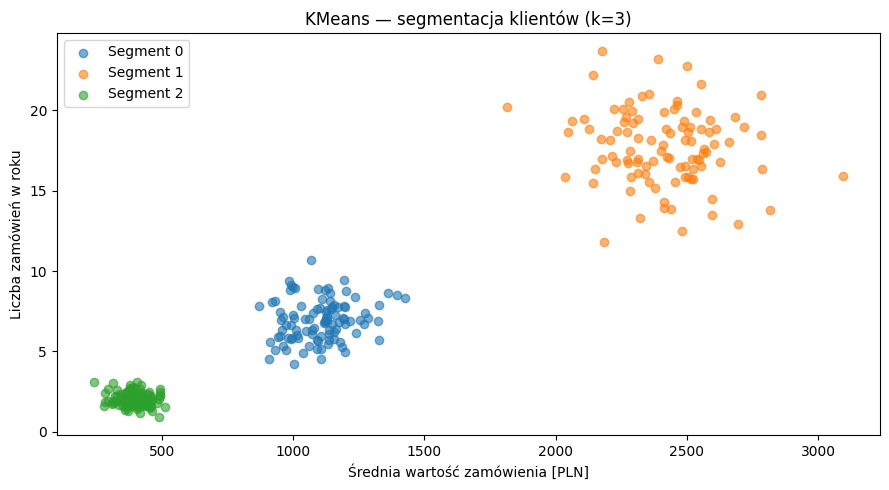

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for seg in sorted(klienci['segment'].unique()):
    grupa = klienci[klienci['segment'] == seg]
    ax.scatter(grupa['srednia_wartosc'], grupa['zamowienia_rok'], label=f'Segment {seg}', alpha=0.6)
ax.set_xlabel('Średnia wartość zamówienia [PLN]')
ax.set_ylabel('Liczba zamówień w roku')
ax.set_title('KMeans — segmentacja klientów (k=3)')
ax.legend()
plt.tight_layout()
plt.show()

> ⚠️ **Pułapka mentalna: „Więcej klastrów = lepiej” oraz „KMeans sam wie, ile jest grup”**
>
> KMeans **nie wie**, ile jest segmentów — *ty* podajesz `k`. I uwaga: im większe `k`, tym mniejsza `inertia_` (suma odległości punktów od środków) — ale `k` równe liczbie klientów dałoby inertię 0 i zero sensu biznesowego (gdyby każdy klient był osobną grupą, leżałby idealnie w swoim środku — odległość 0 — ale taki podział nic nie mówi).
>
> **Metoda łokcia** (elbow method): rysujemy inertię dla kolejnych `k` i szukamy „łokcia” — punktu, po którym dokładanie grup już niewiele daje.

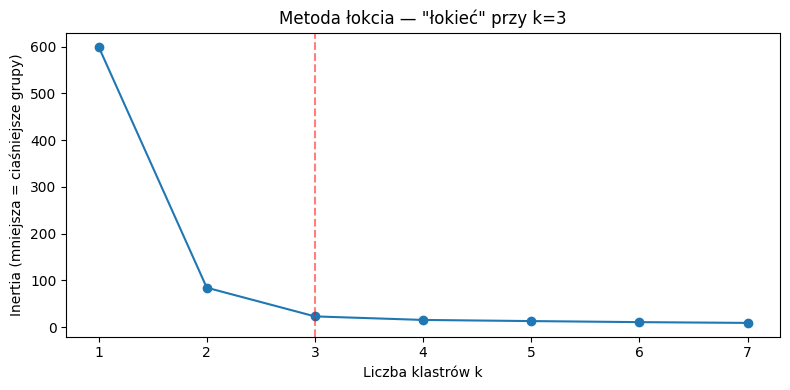

In [8]:
# Metoda łokcia — jak dobrać k
inertie = []
zakres_k = range(1, 8)
for k in zakres_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertie.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(zakres_k), inertie, 'o-')
plt.xlabel('Liczba klastrów k')
plt.ylabel('Inertia (mniejsza = ciaśniejsze grupy)')
plt.title('Metoda łokcia — "łokieć" przy k=3')
plt.axvline(3, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Widać wyraźny „łokieć” przy **k=3** — po nim krzywa się wypłaszcza. To potwierdza nasz wybór. (Tu wiemy, że są 3 grupy, bo sami je stworzyliśmy; w realnych danych łokieć jest Twoją wskazówką.)

### 2.3. Regresja liniowa — prognoza sprzedaży

Drugi smak ML, tym razem **nadzorowany** (supervised): mamy etykietę — znaną wartość, którą chcemy przewidywać. **Regresja liniowa** (model `y = a₁·x₁ + a₂·x₂ + b`) szuka najlepszych współczynników, by przewidzieć liczbę. (`x₁, x₂` to cechy — np. budżet TV i radio; `a₁, a₂` mówią, o ile rośnie sprzedaż przy wzroście danej cechy o 1; `b` to poziom bazowy.)

Scenariusz: znasz wydatki reklamowe (TV, radio) i sprzedaż w 200 regionach. Chcesz model, który odpowie: *„jeśli dołożę budżet na TV, ile zyskam na sprzedaży?”*

In [9]:
# Dane: 200 regionów, prawdziwa zależność sprzedaz = 5 + 0.05*tv + 0.12*radio + szum
np.random.seed(42)
n = 200
reklama = pd.DataFrame({
    'tv': np.random.uniform(10, 300, n),
    'radio': np.random.uniform(5, 50, n),
})
reklama['sprzedaz'] = (5 + 0.05 * reklama['tv'] + 0.12 * reklama['radio']
                       + np.random.normal(0, 1.5, n))
reklama.head(3).round(2)

,tv,radio,sprzedaz
0,118.62,33.89,16.96
1,285.71,8.79,20.37
2,222.28,12.27,18.61


> ⚠️ **Pułapka mentalna: „Model można ocenić na danych, na których się uczył”**
>
> To jak ocenić ucznia tym samym testem, który dostał do domu z odpowiedziami — wynik nic nie mówi o tym, czy *zrozumiał*. Dlatego dzielimy dane: model uczy się na zbiorze **treningowym**, a oceniamy go na **testowym**, którego *nie widział* — sprawdzamy, czy potrafi *uogólnić* (generalizacja) na nowe dane.
>
> `train_test_split` robi to jedną linijką. Standard to 80% trening / 20% test.

In [10]:
X_cechy = reklama[['tv', 'radio']]   # cechy (features) — to, co wiemy
y_cel = reklama['sprzedaz']          # cel (target) — to, co przewidujemy

X_train, X_test, y_train, y_test = train_test_split(
    X_cechy, y_cel, test_size=0.2, random_state=42
)
print(f'Trening: {len(X_train)} regionów | Test: {len(X_test)} regionów')

Trening: 160 regionów | Test: 40 regionów


In [11]:
# Ten sam wzorzec co KMeans: stwórz -> fit -> użyj
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2  = {r2:.3f}')
print(f'RMSE = {rmse:.3f}')
print(f'Współczynniki: TV={model.coef_[0]:.3f} (prawdziwy 0.05), '
      f'Radio={model.coef_[1]:.3f} (prawdziwy 0.12)')

R2  = 0.860
RMSE = 1.824
Współczynniki: TV=0.050 (prawdziwy 0.05), Radio=0.118 (prawdziwy 0.12)


Dwie miary jakości — obie znasz intuicyjnie ze statystyki (W11/W12):

- **R²** (współczynnik determinacji): od 0 do 1, *ile procent zmienności sprzedaży* wyjaśnia model. Tu wyszło ok. 0.86 → model wyjaśnia ~86% zmienności (resztę pochłania losowy szum, który wpisaliśmy w dane). To rozwinięcie pojęcia „ile wariancji tłumaczy zależność” z W11.
- **RMSE** (pierwiastek błędu średniokwadratowego): średni błąd prognozy *w jednostkach celu*. RMSE≈2 → typowo mylimy się o ok. 2 jednostki sprzedaży. Łatwe w interpretacji, bo w tych samych jednostkach co dane.

Współczynniki modelu (≈0.05 i ≈0.12) odtworzyły *prawdziwą* zależność, którą wpisaliśmy w dane. Model „odkrył”, że radio działa mocniej niż TV.

> ⚠️ **Pułapka mentalna: „Wysokie R² = dobry, poprawny model”**
>
> R² łatwo „napompować”, dokładając cechy — rośnie nawet od kolumn losowych. Wysokie R² na danych treningowych, a niskie na testowych = **przeuczenie** (overfitting): model wykuł dane na pamięć zamiast nauczyć się wzorca. Dlatego R² liczymy **na zbiorze testowym**. I pamiętaj: R² mówi o dopasowaniu, nie o *przyczynowości* (korelacja ≠ przyczyna — W11).

In [12]:
# Prognoza dla nowego regionu: budżet TV=200, radio=30
nowy_region = pd.DataFrame({'tv': [200], 'radio': [30]})
prognoza = model.predict(nowy_region)[0]
reczne = 5 + 0.05 * 200 + 0.12 * 30  # sprawdzenie na piechotę
print(f'Prognoza modelu: {prognoza:.1f} tys. PLN')
print(f'Sprawdzenie ręczne (wzór): {reczne:.1f} tys. PLN')

Prognoza modelu: 18.6 tys. PLN
Sprawdzenie ręczne (wzór): 18.6 tys. PLN


### 2.4. Najważniejsza rzecz o scikit-learn

Jak widać, KMeans i regresja działały **identycznie**: `stwórz model → .fit() → użyj`. To nie przypadek — **całe scikit-learn** ma ten sam interfejs. Setki algorytmów, jedna gramatyka.

> **Analogia do Excela**: w Excelu każda funkcja ma inną składnię (`VLOOKUP` zupełnie inną niż `SUMIF`). W scikit-learn jest odwrotnie — gdy nauczysz się `fit`/`predict` na jednym modelu, umiesz obsłużyć każdy następny. Wymiana `KMeans()` na `RandomForestClassifier()` to zmiana jednej linijki.

## 3. Plotly — interaktywne wykresy (1/3)

### 3.1. Po co interaktywność

W W09-W10 robiliśmy wykresy w Matplotlib/Seaborn — świetne do raportu, druku, pracy dyplomowej. Ale to **statyczny obrazek** (PNG): co widać, to widać. **Plotly** generuje wykres jako **HTML + JavaScript** — można po nim *najeżdżać myszą* (hover — podpowiedź z wartościami), *przybliżać* (zoom), *klikać legendę*, by ukrywać serie.

> ⚠️ **Pułapka mentalna: „Plotly zastępuje Matplotlib”**
>
> Nie zastępuje — *uzupełnia*. To dwa narzędzia do dwóch zadań:
>
> | | Matplotlib/Seaborn | Plotly |
> |---|---|---|
> | Format | statyczny PNG/PDF | interaktywny HTML |
> | Najlepsze do | publikacja, druk, praca dyplomowa | dashboard, eksploracja, prezentacja na żywo |
> | Klient może klikać? | nie | tak |
>
> Na rynku pracy znajomość *obu* to standard analityka.

### 3.2. Pierwszy interaktywny wykres — `px.scatter`

**Plotly Express** (`px`) to wysokopoziomowy interfejs: jedna funkcja = cały wykres z interaktywnością. Narysujemy nasze segmenty z sekcji 2 — ale tym razem *klikalne*.

In [13]:
# Numer segmentu jako tekst -> Plotly potraktuje go jako kategorię (osobny kolor), nie liczbę
klienci['segment_txt'] = klienci['segment'].astype(str)

fig = px.scatter(
    klienci,
    x='srednia_wartosc',
    y='zamowienia_rok',
    color='segment_txt',
    title='Segmentacja klientów — KMeans (k=3)',
    labels={
        'srednia_wartosc': 'Średnia wartość zamówienia [PLN]',
        'zamowienia_rok': 'Liczba zamówień w roku',
        'segment_txt': 'Segment',
    },
)
fig.show()

**Wypróbuj teraz** (w działającym notebooku, nie na slajdzie): najedź myszą na punkt → zobaczysz wartości. Kliknij segment w legendzie → ukryjesz/pokażesz grupę. Zaznacz prostokąt → zoom. Podwójny klik → reset. Tego statyczny obrazek nie potrafi.

### 3.3. Słupki i linie — `px.bar`, `px.line`

Średnia wartość zamówienia per segment, z etykietami na słupkach (`text_auto`):

In [14]:
srednie_seg = (klienci.groupby('segment_txt')['srednia_wartosc']
               .mean().round(0).reset_index())

fig_bar = px.bar(
    srednie_seg,
    x='segment_txt', y='srednia_wartosc', color='segment_txt',
    title='Średnia wartość zamówienia per segment',
    labels={'segment_txt': 'Segment', 'srednia_wartosc': 'Średnia wartość [PLN]'},
    text_auto='.0f',
)
fig_bar.update_layout(showlegend=False)
fig_bar.show()

Trend sprzedaży dwóch produktów w czasie — `px.line` z `markers=True`. Najechanie pokaże wartość każdego miesiąca; kliknięcie legendy odfiltruje produkt.

In [15]:
np.random.seed(42)
miesiace = list(range(1, 13))
trend = pd.DataFrame({
    'miesiac': miesiace * 2,
    'sprzedaz': [100 + i*5 + np.random.normal(0, 8) for i in miesiace]
               + [80 + i*8 + np.random.normal(0, 10) for i in miesiace],
    'produkt': ['Produkt A'] * 12 + ['Produkt B'] * 12,
})

fig_line = px.line(
    trend, x='miesiac', y='sprzedaz', color='produkt', markers=True,
    title='Trend sprzedaży — Produkt A vs B',
    labels={'miesiac': 'Miesiąc', 'sprzedaz': 'Sprzedaż [tys. PLN]', 'produkt': 'Produkt'},
)
fig_line.show()

### 3.4. Więcej informacji na jednym wykresie + eksport

Plotly pozwala zakodować dodatkowe wymiary: `size` (rozmiar punktu) i `hover_data` (co pokazać po najechaniu). Trzy zmienne na jednym obrazku: x, y i rozmiar.

In [16]:
fig3 = px.scatter(
    klienci, x='srednia_wartosc', y='zamowienia_rok',
    color='segment_txt', size='srednia_wartosc',
    hover_data=['srednia_wartosc', 'zamowienia_rok'],
    title='Segmentacja — rozmiar punktu = wartość zamówienia',
    labels={'segment_txt': 'Segment'},
    opacity=0.7,
)
fig3.show()

Każdy wykres Plotly można zapisać jako **samodzielny plik HTML** — otworzy się w każdej przeglądarce, bez Pythona. To idealny sposób, żeby wysłać interaktywny wykres klientowi mailem.

In [17]:
fig.write_html('segmentacja.html')
print('Zapisano: segmentacja.html — otwórz w przeglądarce, działa bez Pythona.')

Zapisano: segmentacja.html — otwórz w przeglądarce, działa bez Pythona.


## 4. Polars — szybki DataFrame (1/3)

### 4.1. Czym jest Polars i dlaczego jest szybki

**Polars** to biblioteka do pracy z danymi — jak Pandas (DataFrame, kolumny, filtry, grupowanie). Różnica: Pandas jest napisany głównie w Pythonie/C, a Polars w **Rust** (szybki język kompilowany). Trzy powody, dla których bywa 5–20× szybszy:

1. **Wielowątkowość** — używa wszystkich rdzeni procesora naraz (Pandas zwykle jednego).
2. **Format kolumnowy** — dane ułożone kolumnami w pamięci, co przyspiesza operacje analityczne.
3. **Leniwa ewaluacja** (lazy; ewaluacja = wykonanie obliczeń) — może zaplanować i zoptymalizować całe zapytanie przed wykonaniem (4.4).

Najpierw zbudujmy ten sam DataFrame w Polars (z naszych klientów), żeby porównać składnię.

In [18]:
# Z Pandas do Polars jednym krokiem (i z powrotem: .to_pandas())
kl_pl = pl.from_pandas(klienci[['srednia_wartosc', 'zamowienia_rok', 'segment']])
print(type(kl_pl))
kl_pl.head(3)

<class 'polars.dataframe.frame.DataFrame'>


srednia_wartosc,zamowienia_rok,segment
f64,f64,i32
429.802849,1.585502,2
391.704142,1.719909,2
438.861312,2.373647,2


### 4.2. Wybór i filtrowanie — `select`, `filter`

Tu widać, że Polars **nie jest** Pandas z inną nazwą — ma własną gramatykę opartą na *wyrażeniach* (`pl.col(...)`). Porównanie tych samych operacji:

| Operacja | Pandas | Polars |
|----------|--------|--------|
| Wybór kolumn | `df[['a', 'b']]` | `df.select('a', 'b')` |
| Filtr wierszy | `df[df['a'] > 5]` | `df.filter(pl.col('a') > 5)` |
| Nowa kolumna | `df['c'] = df['a'] * 2` | `df.with_columns((pl.col('a') * 2).alias('c'))` |

In [19]:
# Filtr: klienci o wartości zamówienia powyżej 1500 PLN
drodzy = kl_pl.filter(pl.col('srednia_wartosc') > 1500)
print(f'Klientów premium (>1500 PLN): {drodzy.height}')
drodzy.select('srednia_wartosc', 'zamowienia_rok').head(3)

Klientów premium (>1500 PLN): 100


srednia_wartosc,zamowienia_rok
f64,f64
2464.401725,20.315444
2500.941215,22.773542
2594.949224,14.503581


### 4.3. Grupowanie i agregacja — `group_by` + `agg`

Odpowiednik `groupby` z W08. W Polars wewnątrz `agg` używamy wyrażeń `pl.col(...)`:

In [20]:
profil_pl = (
    kl_pl.group_by('segment')
    .agg(
        pl.col('srednia_wartosc').mean().round(0).alias('sr_wartosc'),
        pl.col('zamowienia_rok').mean().round(1).alias('sr_zamowienia'),
        pl.len().alias('liczba'),
    )
    .sort('segment')
)
profil_pl

segment,sr_wartosc,sr_zamowienia,liczba
i32,f64,f64,u32
0,1103.0,6.9,100
1,2412.0,17.7,100
2,394.0,2.1,100


> 💡 **Brak indeksu.** Pandas ma „indeks” wiersza (pamiętasz `loc`/`iloc` z W06). Polars **nie ma indeksu** — to celowe uproszczenie: każda kolumna jest równoprawna, odwołujesz się po nazwie. Mniej zaskoczeń, mniej `reset_index()`.

### 4.4. Leniwa ewaluacja (lazy) — sekretna broń Polars

Domyślnie Pandas liczy **natychmiast** (eager): każda linijka od razu się wykonuje. Polars potrafi działać **leniwie** (lazy): budujesz *plan* zapytania, a Polars go **optymalizuje** i wykonuje (ewaluacja = wykonanie obliczeń) dopiero przy `.collect()`. Optymalizator potrafi np. zawęzić dane do potrzebnych kolumn, zanim policzy resztę — robi mniej pracy.

To jak różnica między „kup mleko, potem wróć po chleb, potem znów po masło” a daniem całej listy zakupów na raz — sklep ułoży najkrótszą trasę.

In [21]:
# .lazy() buduje plan; .collect() wykonuje zoptymalizowane zapytanie
wynik = (
    kl_pl.lazy()
    .filter(pl.col('zamowienia_rok') > 5)
    .group_by('segment')
    .agg(pl.col('srednia_wartosc').mean().alias('sr_wartosc'))
    .sort('segment')
    .collect()
)
wynik

segment,sr_wartosc
i32,f64
0,1105.400187
1,2411.681326


### 4.5. Benchmark — Polars vs Pandas na 2 mln wierszy

Teraz konkret: generujemy duży zbiór i mierzymy `group_by` w obu bibliotekach. (Czasy zależą od komputera — liczy się *rząd różnicy*, nie dokładne sekundy.)

Tu mówimy o milisekundach na 2 mln wierszy — ale różnica **rośnie z rozmiarem danych**. Przy 10 milionach transakcji z problemu z sekcji 0 te „kilka razy szybciej” zamienia minuty oczekiwania w sekundy.

In [22]:
import time

np.random.seed(42)
n_rows = 2_000_000
big_pd = pd.DataFrame({
    'kategoria': np.random.choice(['A', 'B', 'C', 'D'], n_rows),
    'wartosc': np.random.normal(1000, 200, n_rows),
})
big_pl = pl.from_pandas(big_pd)

t0 = time.perf_counter()
_ = big_pd.groupby('kategoria')['wartosc'].mean()
czas_pd = time.perf_counter() - t0

t0 = time.perf_counter()
_ = big_pl.group_by('kategoria').agg(pl.col('wartosc').mean())
czas_pl = time.perf_counter() - t0

print(f'Pandas: {czas_pd*1000:6.1f} ms')
print(f'Polars: {czas_pl*1000:6.1f} ms')
print(f'Polars szybszy ~{czas_pd/czas_pl:.1f}x na {n_rows:,} wierszach')

Pandas:   99.7 ms
Polars:   15.5 ms
Polars szybszy ~6.4x na 2,000,000 wierszach


> ⚠️ **Pułapka mentalna: „Polars to Pandas z inną nazwą — wystarczy podmienić import”**
>
> Nie wystarczy. Polars ma **inny API**: wyrażenia `pl.col(...)` zamiast `df['kol']`, `filter`/`select` zamiast indeksowania nawiasami, brak indeksu wierszy, leniwy tryb. Przesiadka wymaga nauki — ale logika (kolumny, filtry, grupy) jest ta sama, więc idzie szybko.

### 4.6. Kiedy Polars, a kiedy Pandas?

| Sytuacja | Wybór |
|----------|-------|
| Dane < 1 mln wierszy, szybkie prototypowanie | **Pandas** |
| Dane > kilka mln wierszy, przetwarzanie wsadowe | **Polars** |
| Integracja ze scikit-learn / istniejący kod zespołu | **Pandas** |
| Nowy pipeline danych, zależy nam na szybkości | **Polars** |

**Na rynku pracy:** Pandas to *wymóg*, Polars to *atut*. Znając Pandas (W05-W08), przesiadka na Polars zajmuje jeden dzień — bo myślenie „kolumny + filtry + grupy” jest wspólne.

## 5. Kulminacja — trzy narzędzia w jednym pipeline

Pokażmy, że to nie trzy osobne ciekawostki, lecz **jeden łańcuch**. Zadanie biznesowe: *wczytaj transakcje, policz profil klientów, posegmentuj ich i pokaż interaktywnie*. Rola każdego narzędzia:

1. **Polars** — szybko agreguje surowe transakcje do profilu per klient,
2. **scikit-learn** — segmentuje klientów (KMeans),
3. **Plotly** — pokazuje wynik interaktywnie.

Pełna analiza w kilkunastu linijkach.

In [23]:
# 0) Surowe transakcje (symulacja: 50 000 transakcji, 800 klientów)
np.random.seed(7)
n_tx = 50_000
transakcje = pl.DataFrame({
    'klient_id': np.random.randint(1, 801, n_tx),
    'kwota': np.abs(np.random.normal(250, 120, n_tx)).round(2),
})

# 1) POLARS — profil per klient: liczba zamówień + średnia kwota
profil = (
    transakcje.group_by('klient_id')
    .agg(
        pl.len().alias('liczba_zamowien'),
        pl.col('kwota').mean().round(2).alias('srednia_kwota'),
    )
    .sort('klient_id')
)
print(f'Klientów po agregacji: {profil.height}')
profil.head(3)

Klientów po agregacji: 800


klient_id,liczba_zamowien,srednia_kwota
i64,u32,f64
1,63,265.26
2,58,254.17
3,65,268.72


In [24]:
# 2) SCIKIT-LEARN — segmentacja klientów (most Polars -> Pandas dla sklearn)
profil_pd = profil.to_pandas()
X = StandardScaler().fit_transform(profil_pd[['liczba_zamowien', 'srednia_kwota']])
# fit_predict = fit + odczyt etykiet w jednym kroku (skrót tego z sekcji 2.2)
profil_pd['segment'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
profil_pd['segment'] = profil_pd['segment'].astype(str)

# 3) PLOTLY — interaktywna wizualizacja segmentów
fig_final = px.scatter(
    profil_pd, x='srednia_kwota', y='liczba_zamowien', color='segment',
    title='Pipeline: Polars -> scikit-learn -> Plotly (800 klientów)',
    labels={'srednia_kwota': 'Średnia kwota [PLN]', 'liczba_zamowien': 'Liczba zamówień',
            'segment': 'Segment'},
    opacity=0.6,
)
fig_final.show()

To jest **realny przepływ pracy analityka**: dane → szybka agregacja (Polars) → model (scikit-learn) → komunikacja wyniku (Plotly). Każde narzędzie robi to, w czym jest najlepsze. Fundament z W01-W12 (Pandas, NumPy, statystyka) spina to wszystko.

## 6. Pułapki Pythona i ściąga API

### Pułapka 1: instalujesz `scikit-learn`, importujesz `sklearn`
Nazwa pakietu (`pip install scikit-learn`) ≠ nazwa do importu (`import sklearn`). `pip install sklearn` to przestarzała atrapa — nie używaj.

### Pułapka 2: `fit_transform` na zbiorze testowym (data leakage — wyciek danych)
Na treningu: `scaler.fit_transform(X_train)`. Na teście: **tylko** `scaler.transform(X_test)`. `fit` na teście „podgląda” dane testowe (przecieka informacja ze zbioru testowego do modelu) i zawyża ocenę.

### Pułapka 3: Plotly koloruje liczbami zamiast kategoriami
Gdy `color='segment'` to liczba (0/1/2), Plotly użyje *ciągłej* skali kolorów. Rzutuj na tekst: `df['segment'].astype(str)` → osobny kolor per grupa.

### Pułapka 4: `fig.show()` nic nie wyświetla
Potrzebny pakiet `nbformat` (`uv pip install nbformat`) i restart kernela. W VS Code — sprawdź rozszerzenie Jupyter.

### Pułapka 5: w Polars nie ma *nazwanego* indeksu wierszy
Polars nie ma etykietowego indeksu jak Pandas (`df.loc['etykieta']`). Pozycyjnie wiersz dostaniesz przez `df.row(3)`, ale w praktyce wybierasz wiersze przez `filter`, a nie po pozycji.

### Pułapka 6: zapomniany `.collect()` w trybie lazy
`df.lazy().filter(...)` zwraca *plan* (`LazyFrame`), nie dane. Dopiero `.collect()` go wykonuje.

---

### Ściąga API

```python
# scikit-learn — zawsze ten sam wzorzec
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
# Klasteryzacja (nienadzorowana): skalujemy całość — nie ma zbioru testowego
X = StandardScaler().fit_transform(dane)
labels = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
# Regresja (nadzorowana): NAJPIERW split, dopiero potem trenuj na zbiorze treningowym
Xtr, Xte, ytr, yte = train_test_split(cechy, cel, test_size=0.2, random_state=42)
model = LinearRegression().fit(Xtr, ytr); pred = model.predict(Xte)

# Plotly Express
import plotly.express as px
px.scatter(df, x='a', y='b', color='kat', size='c', hover_data=['d'])
px.bar(df, x='a', y='b', text_auto='.0f'); px.line(df, x='a', y='b', markers=True)
fig.write_html('wykres.html')                    # eksport interaktywny

# Polars
import polars as pl
pl.from_pandas(df) / dfpl.to_pandas()            # most do/z Pandas
dfpl.select('a', 'b').filter(pl.col('a') > 5)
dfpl.group_by('kat').agg(pl.col('a').mean(), pl.len())
dfpl.lazy().filter(...).group_by(...).agg(...).collect()   # leniwa optymalizacja
```

## 7. Mini-zadanie do samodzielnego wykonania (10 min)

Połączenie scikit-learn i Plotly:

1. Wygeneruj **200 klientów** z `np.random.seed(123)`, dwie cechy: `wiek` (18–70) i `wydatki_miesiac` (PLN). Ułóż je w **4 skupiska** (wzór ułożenia skopiuj z komórki `klienci` w sekcji 1 — tam były 3 grupy, tu zrób 4).
2. Zastosuj `KMeans(n_clusters=4)` — **pamiętaj o `StandardScaler`!**
3. Narysuj interaktywny `px.scatter` (`color` = segment jako tekst).
4. Opisz jednym zdaniem każdy z 4 segmentów.

Kto skończy szybciej — dodaje `size='wydatki_miesiac'` i sprawdza metodę łokcia dla `k` od 1 do 7.

In [25]:
# Miejsce na rozwiązanie
np.random.seed(123)
# 1) dane ...
# 2) StandardScaler + KMeans(n_clusters=4) ...
# 3) px.scatter ...


## 8. Podgląd laboratorium

Na laboratorium **dziś po wykładzie** zbudujesz pełną analizę krok po kroku — te same trzy narzędzia, własnymi rękami. **Dane** generowane w kodzie z `np.random.seed(42)` (pełna powtarzalność).

**3 komendy startowe** (Windows, lab uczelniany):

```powershell
cd C:\Users\student\python2
.venv\Scripts\Activate.ps1
code .
```

Utworzysz notebook `lab13_advanced_libs.ipynb` i pójdziesz zgodnie z `cwiczenia.md`. Commit po każdym ćwiczeniu.

**Ćwiczenia na labie (≈90 min):**

1. **KMeans — segmentacja klientów** — `StandardScaler` + `KMeans(k=3)` + interpretacja segmentów
2. **Regresja liniowa — prognoza sprzedaży** — `train_test_split` → `fit` → `predict` → R²/RMSE
3. **Polars — szybka agregacja** — `select`/`filter`/`group_by` + benchmark vs Pandas
4. **Plotly — interaktywny dashboard** — `scatter`/`bar`/`line` + eksport HTML
5. **Mini-projekt** — pełny pipeline (Polars → scikit-learn → Plotly) + commit do git

## Na następnym wykładzie

**W14 — LLM i AI w analizie danych**: wywołasz model językowy (GPT / Claude) przez Python, przetworzysz odpowiedź i zautomatyzujesz prostą analizę. Kto chce się przygotować — zerknij na *OpenAI Python SDK* lub *Anthropic Python SDK* na PyPI.

## Cytat zamykający

> *„A breakthrough in machine learning would be worth ten Microsofts.”*
>
> — **Bill Gates**

**Polski przekład**: „Przełom w uczeniu maszynowym byłby wart dziesięciu Microsoftów.”

---

### 💡 Złota myśl na koniec

> „The goal is to turn data into information, and information into insight.”
>
> — **Carly Fiorina** (była CEO Hewlett-Packard)

**Polski przekład**: „Celem jest zamiana danych w informację, a informacji we wgląd.” To właśnie robiliśmy dziś: surowe transakcje → segmenty (model) → interaktywny obraz → decyzja.

---

### Ciekawostka — skąd się wzięły te biblioteki

- **scikit-learn** zaczął jako projekt Google Summer of Code w 2007 r. (David Cournapeau). Dziś to jedna z najczęściej używanych bibliotek ML na świecie.
- **Plotly** to firma z Montrealu (2012); biblioteka Python jest open-source, a pod spodem renderuje wykresy tą samą technologią (D3.js / WebGL), co interaktywne dashboardy w przeglądarce.
- **Polars** stworzył Ritchie Vink (2020) — sfrustrowany szybkością Pandas na dużych danych; napisał alternatywę w Rust. W kilka lat stał się realną konkurencją.

### Dokumentacja i źródła

- [scikit-learn — User Guide](https://scikit-learn.org/stable/user_guide.html)
- [scikit-learn — KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) | [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Plotly Express](https://plotly.com/python/plotly-express/)
- [Polars — User Guide](https://docs.pola.rs/) | [Polars vs Pandas](https://docs.pola.rs/user-guide/migration/pandas/)